# 05 — Random Forest Model

**Project:** Financial Fraud Detection System  
**Step:** 7.3 — Random Forest Baseline  
**Dataset:** `data/raw/synthetic_fraud_dataset1 (1).csv`

---

## Objective

This notebook trains a **single Random Forest classifier** as an alternative baseline for the Financial Fraud Detection project.  
The model is evaluated on the **same held-out test set** used in Step 7.2 (Logistic Regression baseline) so that future model comparison is valid.

**Scope of this notebook:**
- Load and prepare the dataset (reproduce cleaning from Step 6 / Step 7.1 / Step 7.2)
- Create a stratified 80/20 train/test split (identical to Step 7.1)
- Build and fit the **same** preprocessing pipeline (only on training data)
- Train **ONE** Random Forest model
- Generate predictions and probabilities
- Evaluate Random Forest performance (Accuracy, Precision, Recall, F1, ROC-AUC, PR-AUC)
- Confusion Matrix, ROC Curve, and Precision-Recall Curve
- Feature importance analysis
- Validation checks

**Not in scope:** Logistic Regression, XGBoost, SMOTE, hyperparameter tuning, cross-validation, model serialization, dashboard, model comparison.

> **Preprocessing note:** Random Forest does **not** require feature scaling (StandardScaler).  
> However, the **same** preprocessing pipeline from Step 7.2 is deliberately retained here so that  
> both models are evaluated on identically transformed data, ensuring a fair comparison in the later  
> model evaluation notebook. Do **not** change preprocessing specifically to improve Random Forest.

---
## 1. Import Libraries

In [1]:
import os
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
)

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
warnings.filterwarnings("ignore", category=FutureWarning)

import sklearn
import sys
print(f"Python version:        {sys.version}")
print(f"scikit-learn version:  {sklearn.__version__}")
print(f"pandas version:        {pd.__version__}")
print(f"numpy version:         {np.__version__}")
print("\nAll libraries imported successfully.")

Python version:        3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)]
scikit-learn version:  1.7.2
pandas version:        2.3.3
numpy version:         2.2.6

All libraries imported successfully.


---
## 2. Load Dataset

In [2]:
# Robust relative path from notebooks/ to the raw data file
DATA_PATH = os.path.join("..", "data", "raw", "synthetic_fraud_dataset1 (1).csv")

raw_df = pd.read_csv(DATA_PATH)
print(f"Raw dataset loaded from: {DATA_PATH}")
print(f"Shape: {raw_df.shape[0]:,} rows x {raw_df.shape[1]} columns")

# Verify expected dataset dimensions
assert raw_df.shape[0] == 50_000, f"Expected 50,000 rows, got {raw_df.shape[0]:,}"
assert raw_df.shape[1] == 14, f"Expected 14 columns, got {raw_df.shape[1]}"
print("Dataset dimensions verified.")

# Create a working copy (raw CSV is never modified)
df = raw_df.copy()

# --- Reproduce Step 6 cleaning ---

# 1. Convert Date column from string to datetime
df["Date"] = pd.to_datetime(df["Date"], format="%d %B %Y", errors="coerce")
nat_count = df["Date"].isna().sum()
print(f"\nDate conversion: {nat_count} unparseable dates (NaT)")

# 2. Extract date-based features (consistent with Step 6)
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["Day_of_Week"] = df["Date"].dt.dayofweek  # Monday=0, Sunday=6

print("Date features created: Year, Month, Day, Day_of_Week")
print(f"Working DataFrame shape: {df.shape}")

Raw dataset loaded from: ..\data\raw\synthetic_fraud_dataset1 (1).csv
Shape: 50,000 rows x 14 columns
Dataset dimensions verified.

Date conversion: 0 unparseable dates (NaT)
Date features created: Year, Month, Day, Day_of_Week
Working DataFrame shape: (50000, 18)


---
## 3. Prepare Features and Target

- **Target (`y`):** `Fraud_Label`
- **Features (`X`):** All model input features, excluding identifiers (`Transaction_ID`, `User_ID`), the raw `Date` column, and the target.
- Date-derived features (`Year`, `Month`, `Day`, `Day_of_Week`) are included as numerical features.

In [3]:
# Columns to exclude from model features
exclude_from_X = ["Transaction_ID", "User_ID", "Date", "Fraud_Label"]

# Target
y = df["Fraud_Label"].copy()

# Features (everything except identifiers, raw Date, and target)
X = df.drop(columns=exclude_from_X).copy()

print(f"Target (y): shape = {y.shape}, dtype = {y.dtype}")
print(f"Features (X): shape = {X.shape}")
print(f"\nFeature columns ({X.shape[1]}):")
for i, col in enumerate(X.columns, 1):
    print(f"  {i:2d}. {col:35s} ({X[col].dtype})")

# Verify target distribution
target_counts = y.value_counts().sort_index()
print(f"\nTarget distribution:")
print(f"  0 (Non-Fraud): {target_counts[0]:,}")
print(f"  1 (Fraud):     {target_counts[1]:,}")
print(f"  Fraud rate:    {target_counts[1] / len(y) * 100:.2f}%")

Target (y): shape = (50000,), dtype = int64
Features (X): shape = (50000, 14)

Feature columns (14):
   1. Transaction_Amount                  (float64)
   2. Transaction_Type                    (object)
   3. Account_Balance                     (float64)
   4. Device_Type                         (object)
   5. Location                            (object)
   6. Merchant_Category                   (object)
   7. Previous_Fraudulent_Activity        (int64)
   8. Daily_Transaction_Count             (int64)
   9. Card_Type                           (object)
  10. Card_Age                            (int64)
  11. Year                                (int32)
  12. Month                               (int32)
  13. Day                                 (int32)
  14. Day_of_Week                         (int32)

Target distribution:
  0 (Non-Fraud): 33,933
  1 (Fraud):     16,067
  Fraud rate:    32.13%


---
## 4. Validate Feature/Target Separation

In [4]:
# --- Data leakage assertions ---
assert "Fraud_Label" not in X.columns, "ERROR: Fraud_Label found in X -- target leakage!"
assert "Transaction_ID" not in X.columns, "ERROR: Transaction_ID found in X!"
assert "User_ID" not in X.columns, "ERROR: User_ID found in X!"
assert "Date" not in X.columns, "ERROR: Raw Date column found in X!"
assert len(X) == len(y), "ERROR: X and y have mismatched row counts!"
assert y.isna().sum() == 0, "ERROR: Missing values in target!"
assert set(y.unique()).issubset({0, 1}), "ERROR: Target contains unexpected values!"
print("All feature/target separation validations passed.")

All feature/target separation validations passed.


---
## 5. Train/Test Split

Create a stratified 80/20 train/test split to preserve class distribution.  
Using `random_state=42` for reproducibility — same parameters as Step 7.1 and Step 7.2.  
This ensures Random Forest is evaluated on **exactly the same** held-out test set as Logistic Regression.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train/Test Split Complete")
print("=" * 50)
print(f"  Training set:  X_train {X_train.shape}  |  y_train {y_train.shape}")
print(f"  Testing set:   X_test  {X_test.shape}  |  y_test  {y_test.shape}")
print(f"\n  Total rows:    {len(X_train) + len(X_test):,}")
print(f"  Train rows:    {len(X_train):,}  ({len(X_train) / len(X) * 100:.1f}%)")
print(f"  Test rows:     {len(X_test):,}  ({len(X_test) / len(X) * 100:.1f}%)")
print(f"  random_state:  42")
print(f"  stratify:      y")

# Verify sizes
assert len(X_train) == len(y_train), "X_train and y_train row count mismatch!"
assert len(X_test) == len(y_test), "X_test and y_test row count mismatch!"
print("\nSplit sizes verified.")

Train/Test Split Complete
  Training set:  X_train (40000, 14)  |  y_train (40000,)
  Testing set:   X_test  (10000, 14)  |  y_test  (10000,)

  Total rows:    50,000
  Train rows:    40,000  (80.0%)
  Test rows:     10,000  (20.0%)
  random_state:  42
  stratify:      y

Split sizes verified.


---
## 6. Verify Class Distribution

Confirm that the stratified split preserves the fraud/non-fraud ratio in both training and test sets.

In [6]:
train_dist = y_train.value_counts(normalize=True).sort_index()
test_dist = y_test.value_counts(normalize=True).sort_index()

print("Class Distribution Verification")
print("=" * 50)
print(f"  {'Class':<15} {'Train %':>10} {'Test %':>10}")
print(f"  {'-'*15} {'-'*10} {'-'*10}")
print(f"  {'0 (Non-Fraud)':<15} {train_dist[0]*100:>9.2f}% {test_dist[0]*100:>9.2f}%")
print(f"  {'1 (Fraud)':<15} {train_dist[1]*100:>9.2f}% {test_dist[1]*100:>9.2f}%")
print("\nStratification confirmed — class ratios are preserved.")

Class Distribution Verification
  Class              Train %     Test %
  --------------- ---------- ----------
  0 (Non-Fraud)       67.86%     67.87%
  1 (Fraud)           32.14%     32.13%

Stratification confirmed — class ratios are preserved.


---
## 7. Build Preprocessing Pipeline

Recreate the **identical** preprocessing design from Step 7.2 using `ColumnTransformer`.  

**Categorical features** -> `OneHotEncoder(drop="first", handle_unknown="ignore")`  
**Numerical features** -> `StandardScaler()`

The numerical features include the 4 date-derived components (`Year`, `Month`, `Day`, `Day_of_Week`)  
in addition to the 5 original numerical columns, for a total of 9 numerical features.

> **Note:** Random Forest is a tree-based model and does **not** require feature scaling.  
> The `StandardScaler` is retained here **solely for consistency** with the Logistic Regression  
> pipeline so that both models operate on the same transformed feature space.  
> This enables fair comparisons in the later model evaluation notebook.

In [7]:
# Define feature groups explicitly
categorical_features = [
    "Transaction_Type",
    "Device_Type",
    "Location",
    "Merchant_Category",
    "Card_Type",
]

numerical_features = [
    "Transaction_Amount",
    "Account_Balance",
    "Previous_Fraudulent_Activity",
    "Daily_Transaction_Count",
    "Card_Age",
    "Year",
    "Month",
    "Day",
    "Day_of_Week",
]

# Verify all specified columns exist in the DataFrame
for col in categorical_features + numerical_features:
    assert col in X_train.columns, f"ERROR: Column '{col}' not found in X_train!"

# Build ColumnTransformer (consistent with Step 7.2 design)
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore"),
            categorical_features,
        ),
        (
            "num",
            StandardScaler(),
            numerical_features,
        ),
    ],
    remainder="drop",
)

print("Preprocessing ColumnTransformer defined:")
print(f"  Categorical -> OneHotEncoder (drop='first', handle_unknown='ignore')")
print(f"    Columns ({len(categorical_features)}): {categorical_features}")
print(f"  Numerical  -> StandardScaler")
print(f"    Columns ({len(numerical_features)}):  {numerical_features}")
print(f"\n  Total input features: {len(categorical_features) + len(numerical_features)}")

Preprocessing ColumnTransformer defined:
  Categorical -> OneHotEncoder (drop='first', handle_unknown='ignore')
    Columns (5): ['Transaction_Type', 'Device_Type', 'Location', 'Merchant_Category', 'Card_Type']
  Numerical  -> StandardScaler
    Columns (9):  ['Transaction_Amount', 'Account_Balance', 'Previous_Fraudulent_Activity', 'Daily_Transaction_Count', 'Card_Age', 'Year', 'Month', 'Day', 'Day_of_Week']

  Total input features: 14


---
## 8. Fit Preprocessing on Training Data Only

**Critical for preventing data leakage.**

The preprocessor is fitted **exclusively** on `X_train`.  
The test set (`X_test`) remains completely unseen during the fitting process.

In [8]:
# Fit the preprocessor ONLY on training data
preprocessor.fit(X_train)

# Transform both sets using the preprocessor fitted on X_train
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Get feature names from the fitted preprocessor
transformed_feature_names = preprocessor.get_feature_names_out()

print("Preprocessor fitted on X_train ONLY.")
print(f"  Training samples used for fitting: {len(X_train):,}")
print(f"  Test samples kept unseen: {len(X_test):,}")
print(f"\nTransformation Complete")
print("=" * 50)
print(f"  X_train_processed shape: {X_train_processed.shape}")
print(f"  X_test_processed shape:  {X_test_processed.shape}")
print(f"  Number of transformed features: {len(transformed_feature_names)}")

# Validate processed shapes
assert X_train_processed.shape[0] == X_train.shape[0], "Train row count mismatch after transform!"
assert X_test_processed.shape[0] == X_test.shape[0], "Test row count mismatch after transform!"
assert X_train_processed.shape[1] == X_test_processed.shape[1], "Train/test column count mismatch!"

# Verify preprocessor was fitted on training data only
num_transformer = preprocessor.named_transformers_["num"]
assert num_transformer.n_samples_seen_ == len(X_train), \
    f"Preprocessor fitted on {num_transformer.n_samples_seen_} samples, expected {len(X_train)}!"
print(f"\nConfirmed: preprocessor fitted on {num_transformer.n_samples_seen_:,} training samples only.")

Preprocessor fitted on X_train ONLY.
  Training samples used for fitting: 40,000
  Test samples kept unseen: 10,000

Transformation Complete
  X_train_processed shape: (40000, 25)
  X_test_processed shape:  (10000, 25)
  Number of transformed features: 25

Confirmed: preprocessor fitted on 40,000 training samples only.


---
## 9. Verify Transformed Data Integrity

Ensure no NaN or infinite values remain in the processed matrices.

In [9]:
# Check for NaN values
assert not np.isnan(X_train_processed).any(), "ERROR: NaN values found in X_train_processed!"
assert not np.isnan(X_test_processed).any(), "ERROR: NaN values found in X_test_processed!"

# Check for infinite values
assert not np.isinf(X_train_processed).any(), "ERROR: Infinite values found in X_train_processed!"
assert not np.isinf(X_test_processed).any(), "ERROR: Infinite values found in X_test_processed!"

print("Data integrity checks passed:")
print("  - No NaN values in processed matrices")
print("  - No infinite values in processed matrices")
print(f"  - X_train_processed: {X_train_processed.shape}")
print(f"  - X_test_processed:  {X_test_processed.shape}")

Data integrity checks passed:
  - No NaN values in processed matrices
  - No infinite values in processed matrices
  - X_train_processed: (40000, 25)
  - X_test_processed:  (10000, 25)


---
## 10. Train Random Forest Baseline

Train a **single** Random Forest model as the **Step 7.3 baseline**.  
No hyperparameter tuning, no GridSearchCV, no cross-validation — a single, reproducible baseline.

**Configuration:**
- `n_estimators=200` — 200 trees for a strong baseline
- `random_state=42` — for reproducibility
- `n_jobs=-1` — use all available CPU cores for efficient training
- `class_weight=None` — use the natural class distribution (consistent with Step 7.2)

In [10]:
# Train ONE Random Forest baseline model
random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight=None,
)

random_forest_model.fit(X_train_processed, y_train)

print("Random Forest Baseline -- Training Complete")
print("=" * 50)
print(f"  Model: {random_forest_model.__class__.__name__}")
print(f"  n_estimators: {random_forest_model.n_estimators}")
print(f"  random_state: {random_forest_model.random_state}")
print(f"  n_jobs: {random_forest_model.n_jobs}")
print(f"  class_weight: {random_forest_model.class_weight}")
print(f"  Number of features seen: {random_forest_model.n_features_in_}")
print(f"  Number of training samples: {X_train_processed.shape[0]:,}")
print(f"  Classes: {random_forest_model.classes_}")

# Verify model is fitted
assert hasattr(random_forest_model, 'estimators_'), "ERROR: Model was not fitted!"
assert len(random_forest_model.estimators_) == 200, "ERROR: Expected 200 estimators!"
assert random_forest_model.n_features_in_ == X_train_processed.shape[1], \
    "ERROR: Model feature count does not match processed data!"
print("\nRandom Forest model trained and verified.")

Random Forest Baseline -- Training Complete
  Model: RandomForestClassifier
  n_estimators: 200
  random_state: 42
  n_jobs: -1
  class_weight: None
  Number of features seen: 25
  Number of training samples: 40,000
  Classes: [0 1]

Random Forest model trained and verified.


---
## 11. Generate Predictions and Probabilities

In [11]:
# Verify class ordering before extracting probabilities
print(f"Model class ordering: {random_forest_model.classes_}")
assert list(random_forest_model.classes_) == [0, 1], \
    f"ERROR: Unexpected class ordering: {random_forest_model.classes_}"
print("  -> Class 1 (Fraud) probability is at index 1.\n")

# Generate predictions (hard labels)
y_train_pred = random_forest_model.predict(X_train_processed)
y_test_pred = random_forest_model.predict(X_test_processed)

# Generate probabilities (for ROC-AUC and PR-AUC)
y_train_proba_full = random_forest_model.predict_proba(X_train_processed)
y_test_proba_full = random_forest_model.predict_proba(X_test_processed)

# Verify probability matrix dimensions
assert y_train_proba_full.shape == (len(y_train), 2), \
    f"ERROR: Train probability matrix shape {y_train_proba_full.shape} unexpected!"
assert y_test_proba_full.shape == (len(y_test), 2), \
    f"ERROR: Test probability matrix shape {y_test_proba_full.shape} unexpected!"

# Extract positive-class probabilities (P(Fraud=1))
y_train_proba = y_train_proba_full[:, 1]
y_test_proba = y_test_proba_full[:, 1]

print("Predictions and Probabilities Generated")
print("=" * 50)
print(f"  y_train_pred shape:  {y_train_pred.shape}")
print(f"  y_test_pred shape:   {y_test_pred.shape}")
print(f"  y_train_proba shape: {y_train_proba.shape}")
print(f"  y_test_proba shape:  {y_test_proba.shape}")

# Validate predictions
assert len(y_train_pred) == len(y_train), "Train prediction length mismatch!"
assert len(y_test_pred) == len(y_test), "Test prediction length mismatch!"
assert len(y_train_proba) == len(y_train), "Train probability length mismatch!"
assert len(y_test_proba) == len(y_test), "Test probability length mismatch!"
assert set(np.unique(y_train_pred)).issubset({0, 1}), "Train predictions contain invalid values!"
assert set(np.unique(y_test_pred)).issubset({0, 1}), "Test predictions contain invalid values!"
assert y_train_proba.min() >= 0 and y_train_proba.max() <= 1, "Train probabilities out of [0,1]!"
assert y_test_proba.min() >= 0 and y_test_proba.max() <= 1, "Test probabilities out of [0,1]!"

print(f"\n  Train prediction unique values: {np.unique(y_train_pred)}")
print(f"  Test prediction unique values:  {np.unique(y_test_pred)}")
print(f"  Train probability range:  [{y_train_proba.min():.4f}, {y_train_proba.max():.4f}]")
print(f"  Test probability range:   [{y_test_proba.min():.4f}, {y_test_proba.max():.4f}]")
print("\nAll prediction validations passed.")

Model class ordering: [0 1]
  -> Class 1 (Fraud) probability is at index 1.

Predictions and Probabilities Generated
  y_train_pred shape:  (40000,)
  y_test_pred shape:   (10000,)
  y_train_proba shape: (40000,)
  y_test_proba shape:  (10000,)

  Train prediction unique values: [0 1]
  Test prediction unique values:  [0 1]
  Train probability range:  [0.0300, 0.8800]
  Test probability range:   [0.1500, 0.5750]

All prediction validations passed.


---
## 12. Evaluate Random Forest

Calculate baseline metrics for both training and test sets.  
The **test set** metrics are the primary results.

Metrics include **PR-AUC (Average Precision)** as an additional fraud-detection metric,  
since Precision-Recall analysis is more informative than ROC for imbalanced classification problems.

In [12]:
# Calculate metrics for training set
train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred, zero_division=0)
train_recall = recall_score(y_train, y_train_pred, zero_division=0)
train_f1 = f1_score(y_train, y_train_pred, zero_division=0)
train_roc_auc = roc_auc_score(y_train, y_train_proba)
train_pr_auc = average_precision_score(y_train, y_train_proba)

# Calculate metrics for test set
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, zero_division=0)
test_recall = recall_score(y_test, y_test_pred, zero_division=0)
test_f1 = f1_score(y_test, y_test_pred, zero_division=0)
test_roc_auc = roc_auc_score(y_test, y_test_proba)
test_pr_auc = average_precision_score(y_test, y_test_proba)

print("Random Forest Baseline -- Evaluation")
print("=" * 50)
print(f"\n  {'Metric':<15s} {'Train':>10s} {'Test':>10s}")
print(f"  {'-'*15} {'-'*10} {'-'*10}")
print(f"  {'Accuracy':<15s} {train_accuracy:>10.4f} {test_accuracy:>10.4f}")
print(f"  {'Precision':<15s} {train_precision:>10.4f} {test_precision:>10.4f}")
print(f"  {'Recall':<15s} {train_recall:>10.4f} {test_recall:>10.4f}")
print(f"  {'F1-Score':<15s} {train_f1:>10.4f} {test_f1:>10.4f}")
print(f"  {'ROC-AUC':<15s} {train_roc_auc:>10.4f} {test_roc_auc:>10.4f}")
print(f"  {'PR-AUC':<15s} {train_pr_auc:>10.4f} {test_pr_auc:>10.4f}")

print(f"\n--- Test Set Classification Report ---\n")
print(classification_report(
    y_test, y_test_pred,
    target_names=["Non-Fraud (0)", "Fraud (1)"],
    zero_division=0
))

Random Forest Baseline -- Evaluation

  Metric               Train       Test
  --------------- ---------- ----------
  Accuracy            1.0000     0.6775
  Precision           1.0000     0.3333
  Recall              1.0000     0.0037
  F1-Score            1.0000     0.0074
  ROC-AUC             1.0000     0.5023
  PR-AUC              1.0000     0.3275

--- Test Set Classification Report ---

               precision    recall  f1-score   support

Non-Fraud (0)       0.68      1.00      0.81      6787
    Fraud (1)       0.33      0.00      0.01      3213

     accuracy                           0.68     10000
    macro avg       0.51      0.50      0.41     10000
 weighted avg       0.57      0.68      0.55     10000



---
## 13. Confusion Matrix

Visualize the test-set confusion matrix for the Random Forest baseline.

Test Set Confusion Matrix
  True Negative  (TN): 6,763
  False Positive (FP): 24
  False Negative (FN): 3,201
  True Positive  (TP): 12


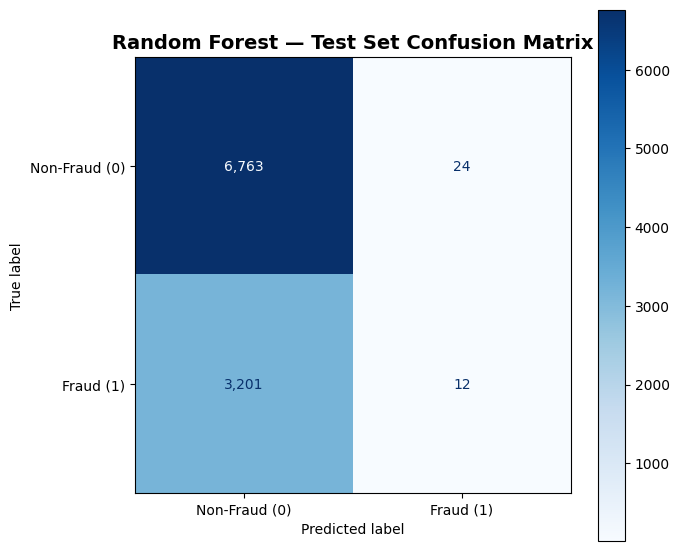

In [13]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
tn, fp, fn, tp = cm.ravel()

print("Test Set Confusion Matrix")
print("=" * 40)
print(f"  True Negative  (TN): {tn:,}")
print(f"  False Positive (FP): {fp:,}")
print(f"  False Negative (FN): {fn:,}")
print(f"  True Positive  (TP): {tp:,}")

# Visualize
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Fraud (0)", "Fraud (1)"]
)
disp.plot(cmap="Blues", values_format=",d", ax=ax)
ax.set_title("Random Forest — Test Set Confusion Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 14. ROC Curve

Visualize the ROC curve for the Random Forest baseline using test-set probabilities.  
Only the Random Forest curve is plotted — multi-model comparison belongs to a later notebook.

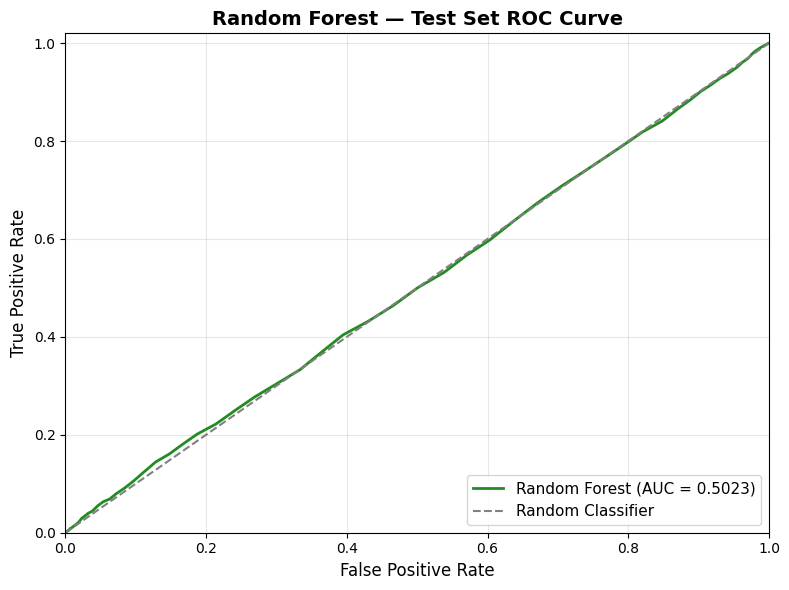

In [14]:
# Compute ROC curve
fpr, tpr, thresholds_roc = roc_curve(y_test, y_test_proba)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color="forestgreen", lw=2,
        label=f"Random Forest (AUC = {test_roc_auc:.4f})")
ax.plot([0, 1], [0, 1], color="gray", lw=1.5, linestyle="--", label="Random Classifier")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("Random Forest — Test Set ROC Curve", fontsize=14, fontweight="bold")
ax.legend(loc="lower right", fontsize=11)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## 15. Precision-Recall Curve

Because this is a **fraud detection** problem with class imbalance, the Precision-Recall curve  
provides a more informative view of model performance than the ROC curve.  
PR-AUC (Average Precision) is included as an additional fraud-detection metric.

Only the Random Forest curve is plotted — do **not** compare PR-AUC with other models yet.

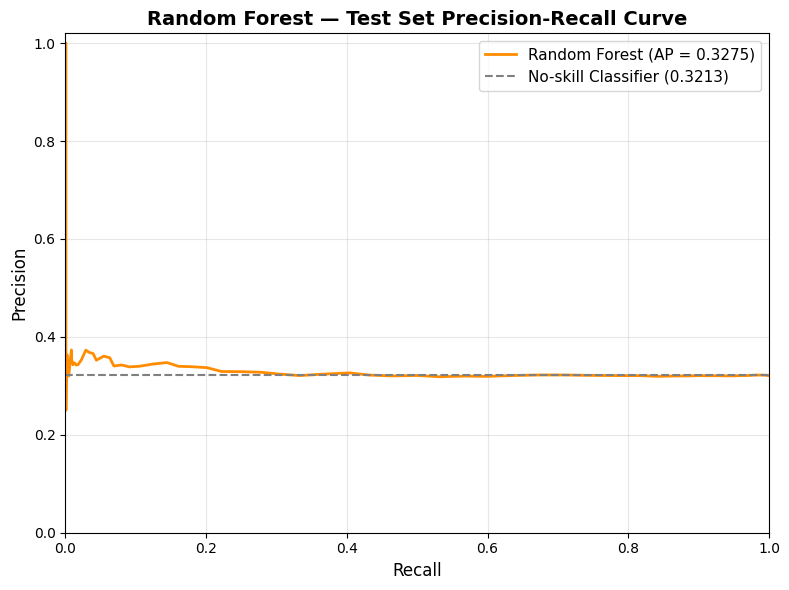

In [15]:
# Compute Precision-Recall curve
precision_vals, recall_vals, thresholds_pr = precision_recall_curve(y_test, y_test_proba)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(recall_vals, precision_vals, color="darkorange", lw=2,
        label=f"Random Forest (AP = {test_pr_auc:.4f})")

# Baseline: fraction of positives in the dataset
baseline_precision = y_test.sum() / len(y_test)
ax.axhline(y=baseline_precision, color="gray", lw=1.5, linestyle="--",
           label=f"No-skill Classifier ({baseline_precision:.4f})")

ax.set_xlabel("Recall", fontsize=12)
ax.set_ylabel("Precision", fontsize=12)
ax.set_title("Random Forest — Test Set Precision-Recall Curve", fontsize=14, fontweight="bold")
ax.legend(loc="upper right", fontsize=11)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## 16. Random Forest Results Table

Concise summary of Random Forest performance on both training and test sets.  
The **test results** are the primary results.

> **Important:** This table contains **only** Random Forest results.  
> Do not include Logistic Regression results here.  
> Do not claim Random Forest is the "best model."  
> Formal model comparison belongs to a later dedicated notebook.

In [16]:
# Build results DataFrame
results_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "PR-AUC"],
    "Train": [
        f"{train_accuracy:.4f}",
        f"{train_precision:.4f}",
        f"{train_recall:.4f}",
        f"{train_f1:.4f}",
        f"{train_roc_auc:.4f}",
        f"{train_pr_auc:.4f}",
    ],
    "Test": [
        f"{test_accuracy:.4f}",
        f"{test_precision:.4f}",
        f"{test_recall:.4f}",
        f"{test_f1:.4f}",
        f"{test_roc_auc:.4f}",
        f"{test_pr_auc:.4f}",
    ],
})

print("\nRandom Forest Results Table")
print("=" * 45)
print(results_df.to_string(index=False))


Random Forest Results Table
   Metric  Train   Test
 Accuracy 1.0000 0.6775
Precision 1.0000 0.3333
   Recall 1.0000 0.0037
       F1 1.0000 0.0074
  ROC-AUC 1.0000 0.5023
   PR-AUC 1.0000 0.3275


---
## 17. Feature Importance

Random Forest provides built-in **feature importance** (Gini importance / mean decrease in impurity).  
The importance values come from `random_forest_model.feature_importances_`.

Display the **top 15** most important transformed features.

> **Note:** One-hot encoded categorical variables will appear as **separate** transformed features  
> (e.g., `cat__Transaction_Type_POS`, `cat__Device_Type_Mobile`).  
> The importance of a categorical variable is distributed across its encoded dummies.

Top 15 Feature Importances (Random Forest)
                            Feature  Importance
            num__Transaction_Amount    0.146835
               num__Account_Balance    0.145886
                      num__Card_Age    0.137401
                           num__Day    0.101356
       num__Daily_Transaction_Count    0.084727
                         num__Month    0.078324
                   num__Day_of_Week    0.059454
            cat__Device_Type_Mobile    0.017211
            cat__Device_Type_Tablet    0.016852
          cat__Card_Type_Mastercard    0.015603
cat__Transaction_Type_Bank Transfer    0.015229
                cat__Card_Type_Visa    0.015134
            cat__Card_Type_Discover    0.015105
       cat__Transaction_Type_Online    0.014974
      cat__Merchant_Category_Travel    0.014966


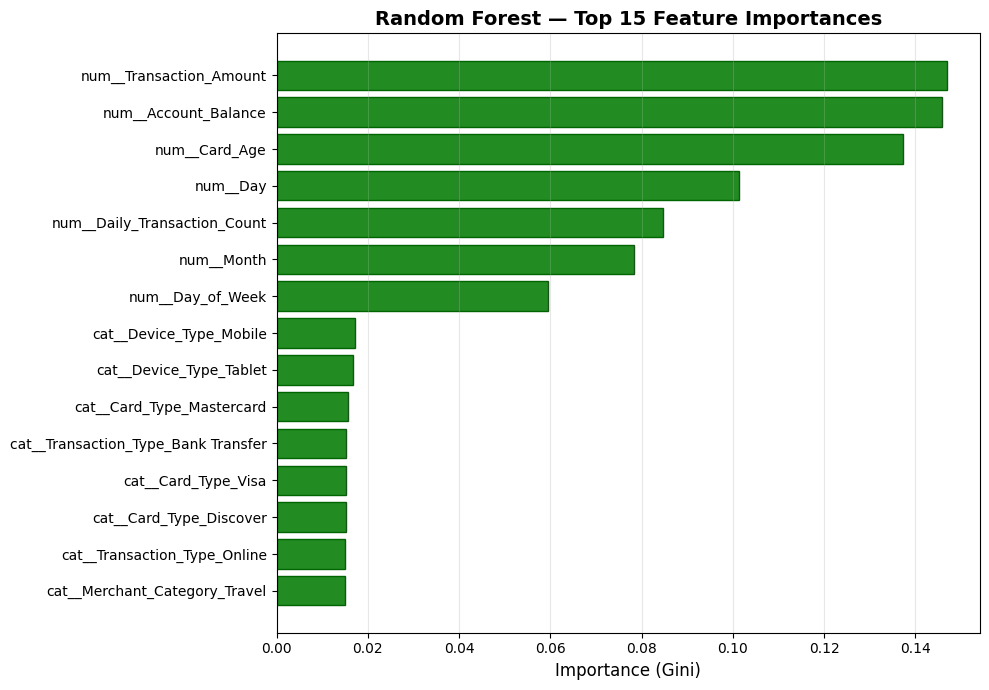

In [17]:
# Retrieve feature importances from the fitted Random Forest
importances = random_forest_model.feature_importances_

# Verify lengths match
assert len(importances) == len(transformed_feature_names), \
    f"ERROR: importance length ({len(importances)}) != feature names length ({len(transformed_feature_names)})!"

# Build importance DataFrame
importance_df = pd.DataFrame({
    "Feature": transformed_feature_names,
    "Importance": importances,
}).sort_values(by="Importance", ascending=False).reset_index(drop=True)

# Display top 15
top_n = 15
print(f"Top {top_n} Feature Importances (Random Forest)")
print("=" * 55)
print(importance_df.head(top_n).to_string(index=False))

# Horizontal bar chart
top_features = importance_df.head(top_n).iloc[::-1]  # reverse for horizontal bar

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top_features["Feature"], top_features["Importance"], color="forestgreen", edgecolor="darkgreen")
ax.set_xlabel("Importance (Gini)", fontsize=12)
ax.set_title(f"Random Forest — Top {top_n} Feature Importances", fontsize=14, fontweight="bold")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

---
## 18. Potential Leakage Documentation

> **\u26a0\ufe0f `Previous_Fraudulent_Activity` — Potential Leakage Concern**
>
> `Previous_Fraudulent_Activity` is **retained** in this notebook for consistency with the
> current modeling workflow (identical feature set as Step 7.2).  
>
> However, the **reference analysis** identifies it as a **potential leakage concern**:
> if this feature represents information that is only known **after** a transaction has been  
> investigated (i.e., retrospective labeling), it may artificially inflate model performance.
>
> **Actions taken in this notebook:**
> - The feature is **not removed** — doing so would make this model incomparable with the Logistic Regression baseline.
> - `Fraud_Label` is **never** used to construct or derive `Previous_Fraudulent_Activity` in this notebook.
>
> **This issue should be reviewed during final model selection/reporting.**  
> If it is confirmed as leakage, all models should be retrained without it.

---
## 19. Findings and Interpretation

In [18]:
# Generate findings based on actual computed metrics
train_test_acc_diff = abs(train_accuracy - test_accuracy)
train_test_f1_diff = abs(train_f1 - test_f1)

print("=" * 60)
print("STEP 7.3 -- RANDOM FOREST BASELINE FINDINGS")
print("=" * 60)

print(f"\n1. MODEL TRAINING STATUS:")
print(f"   The Random Forest model trained successfully.")
print(f"   n_estimators = {random_forest_model.n_estimators}")
print(f"   random_state = {random_forest_model.random_state}")
print(f"   class_weight = {random_forest_model.class_weight}")

print(f"\n2. TEST SET PERFORMANCE:")
print(f"   Accuracy:  {test_accuracy:.4f}")
print(f"   Precision: {test_precision:.4f}")
print(f"   Recall:    {test_recall:.4f}")
print(f"   F1-Score:  {test_f1:.4f}")
print(f"   ROC-AUC:   {test_roc_auc:.4f}")
print(f"   PR-AUC:    {test_pr_auc:.4f}")

print(f"\n3. TRAIN/TEST CONSISTENCY:")
print(f"   Accuracy difference (train vs test): {train_test_acc_diff:.4f}")
print(f"   F1-Score difference (train vs test): {train_test_f1_diff:.4f}")
if train_test_acc_diff < 0.02 and train_test_f1_diff < 0.02:
    print(f"   -> Train and test performance are reasonably consistent.")
    print(f"   -> No significant overfitting detected.")
elif train_test_acc_diff < 0.10:
    print(f"   -> There is a gap between train and test performance.")
    print(f"   -> Some overfitting may be present, which is common for")
    print(f"      Random Forest with default max_depth (unlimited).")
else:
    print(f"   -> Notable gap between train and test. Overfitting is likely a concern.")
    print(f"   -> Consider limiting max_depth in future tuning.")

print(f"\n4. WHAT THE RANDOM FOREST BASELINE TELLS US:")
print(f"   - The Random Forest baseline provides a reference point for tree-based")
print(f"     ensemble models on this fraud detection dataset.")
print(f"   - It establishes whether ensemble methods offer improvement over")
print(f"     simpler linear models (Logistic Regression from Step 7.2).")
print(f"   - The results should NOT be interpreted in isolation.")
print(f"   - Random Forest is NOT declared the best or final model.")

print(f"\n5. NEXT STEPS (NOT IMPLEMENTED HERE):")
print(f"   - Formal model comparison across all trained baselines.")
print(f"   - Additional models (XGBoost, etc.) may be evaluated in later steps.")
print(f"   - Hyperparameter tuning may be explored if justified.")
print(f"   - The Previous_Fraudulent_Activity leakage concern should be reviewed.")
print(f"   - No model comparison, selection, or serialization is performed here.")

print(f"\n" + "=" * 60)

STEP 7.3 -- RANDOM FOREST BASELINE FINDINGS

1. MODEL TRAINING STATUS:
   The Random Forest model trained successfully.
   n_estimators = 200
   random_state = 42
   class_weight = None

2. TEST SET PERFORMANCE:
   Accuracy:  0.6775
   Precision: 0.3333
   Recall:    0.0037
   F1-Score:  0.0074
   ROC-AUC:   0.5023
   PR-AUC:    0.3275

3. TRAIN/TEST CONSISTENCY:
   Accuracy difference (train vs test): 0.3225
   F1-Score difference (train vs test): 0.9926
   -> Notable gap between train and test. Overfitting is likely a concern.
   -> Consider limiting max_depth in future tuning.

4. WHAT THE RANDOM FOREST BASELINE TELLS US:
   - The Random Forest baseline provides a reference point for tree-based
     ensemble models on this fraud detection dataset.
   - It establishes whether ensemble methods offer improvement over
     simpler linear models (Logistic Regression from Step 7.2).
   - The results should NOT be interpreted in isolation.
   - Random Forest is NOT declared the best or fin

---
## 20. Validation Checks

Comprehensive validation to confirm correctness and absence of data leakage.

In [19]:
print("Running Validation Checks...")
print("=" * 55)

checks_passed = 0
total_checks = 13

# 1. Model is fitted
assert hasattr(random_forest_model, 'estimators_'), "FAIL: Model is not fitted!"
print("  [PASS] 1.  Model is fitted.")
checks_passed += 1

# 2. Number of training samples is 40,000
assert X_train_processed.shape[0] == 40_000, \
    f"FAIL: Expected 40,000 training samples, got {X_train_processed.shape[0]}!"
print("  [PASS] 2.  Number of training samples is 40,000.")
checks_passed += 1

# 3. Number of predictions equals number of test samples
assert len(y_test_pred) == len(y_test), "FAIL: Prediction count != test sample count!"
print("  [PASS] 3.  Number of predictions equals number of test samples.")
checks_passed += 1

# 4. Prediction values are binary
assert set(np.unique(y_test_pred)).issubset({0, 1}), "FAIL: Non-binary predictions!"
print("  [PASS] 4.  Prediction values are binary.")
checks_passed += 1

# 5. Probability values are between 0 and 1
assert y_test_proba.min() >= 0 and y_test_proba.max() <= 1, "FAIL: Probabilities out of [0,1]!"
print("  [PASS] 5.  Probability values are between 0 and 1.")
checks_passed += 1

# 6. Probability matrix has expected dimensions
assert y_test_proba_full.shape == (len(y_test), 2), "FAIL: Probability matrix dimensions wrong!"
print("  [PASS] 6.  Probability matrix has expected dimensions.")
checks_passed += 1

# 7. Processed train and test feature counts match
assert X_train_processed.shape[1] == X_test_processed.shape[1], "FAIL: Feature count mismatch!"
print("  [PASS] 7.  Processed train and test feature counts match.")
checks_passed += 1

# 8. No NaN values in processed matrices
assert not np.isnan(X_train_processed).any(), "FAIL: NaN in X_train_processed!"
assert not np.isnan(X_test_processed).any(), "FAIL: NaN in X_test_processed!"
print("  [PASS] 8.  No NaN values in processed matrices.")
checks_passed += 1

# 9. No infinite values
assert not np.isinf(X_train_processed).any(), "FAIL: Inf in X_train_processed!"
assert not np.isinf(X_test_processed).any(), "FAIL: Inf in X_test_processed!"
print("  [PASS] 9.  No infinite values in processed matrices.")
checks_passed += 1

# 10. Fraud_Label is not in X
assert "Fraud_Label" not in X.columns, "FAIL: Fraud_Label in X!"
print("  [PASS] 10. Fraud_Label is not in X.")
checks_passed += 1

# 11. Transaction_ID is not in X
assert "Transaction_ID" not in X.columns, "FAIL: Transaction_ID in X!"
print("  [PASS] 11. Transaction_ID is not in X.")
checks_passed += 1

# 12. User_ID is not in X
assert "User_ID" not in X.columns, "FAIL: User_ID in X!"
print("  [PASS] 12. User_ID is not in X.")
checks_passed += 1

# 13. Preprocessor was fitted only on X_train
num_transformer = preprocessor.named_transformers_["num"]
assert num_transformer.n_samples_seen_ == len(X_train), \
    f"FAIL: Preprocessor fitted on {num_transformer.n_samples_seen_} samples, not {len(X_train)}!"
print("  [PASS] 13. Preprocessor was fitted only on X_train.")
checks_passed += 1

print(f"\n  {checks_passed}/{total_checks} validation checks PASSED.")
assert checks_passed == total_checks, f"FAIL: {total_checks - checks_passed} checks failed!"
print("  All validation checks passed successfully!")

Running Validation Checks...
  [PASS] 1.  Model is fitted.
  [PASS] 2.  Number of training samples is 40,000.
  [PASS] 3.  Number of predictions equals number of test samples.
  [PASS] 4.  Prediction values are binary.
  [PASS] 5.  Probability values are between 0 and 1.
  [PASS] 6.  Probability matrix has expected dimensions.
  [PASS] 7.  Processed train and test feature counts match.
  [PASS] 8.  No NaN values in processed matrices.
  [PASS] 9.  No infinite values in processed matrices.
  [PASS] 10. Fraud_Label is not in X.
  [PASS] 11. Transaction_ID is not in X.
  [PASS] 12. User_ID is not in X.
  [PASS] 13. Preprocessor was fitted only on X_train.

  13/13 validation checks PASSED.
  All validation checks passed successfully!


---
## 21. Step 7.3 — Completion Statement

**Step 7.3 — Random Forest Model is COMPLETE.**

### What was accomplished:
- \u2705 Dataset loaded and prepared identically to Step 7.2
- \u2705 Same 80/20 stratified train/test split (random_state=42)
- \u2705 Same preprocessing pipeline fitted ONLY on X_train
- \u2705 ONE Random Forest classifier trained (n_estimators=200, random_state=42, n_jobs=-1)
- \u2705 Predictions and probabilities generated
- \u2705 Accuracy, Precision, Recall, F1, ROC-AUC, and PR-AUC calculated
- \u2705 Confusion matrix generated
- \u2705 ROC curve generated
- \u2705 Precision-Recall curve generated
- \u2705 Feature importance analysis completed
- \u2705 `Previous_Fraudulent_Activity` documented as potential leakage concern
- \u2705 All validation checks passed

### What was NOT done (by design):
- \u274c No Logistic Regression trained
- \u274c No XGBoost or other models trained
- \u274c No SMOTE or resampling applied
- \u274c No hyperparameter tuning performed
- \u274c No cross-validation performed
- \u274c No model comparison performed
- \u274c No final model selected
- \u274c No model artifact saved (.pkl, .joblib)
- \u274c No dashboard or deployment work

---

**STOP. Step 7.3 is complete. Do NOT proceed to Step 7.4 or any later step.**